# Part 2 -- Model Training & Strategy Formulation

**PRECOG Quant Trading Task**

This notebook consumes `data/processed/features.parquet` from Part 1 and:

1. Builds the prediction **target**: the 5-day forward return,
   cross-sectionally demeaned (i.e. "excess return vs the equal-weight
   universe over the next 5 trading days").
2. Trains a **walk-forward ensemble** (Ridge + LightGBM + Logistic
   Regression) -- refit annually on an expanding window, with an embargo so
   no training label's forward-return window crosses into the holdout year.
3. Evaluates the ensemble's **Information Coefficient (IC)** out-of-sample,
   2020-2026, overall / by fold / by model.
4. Selects the **portfolio rebalance frequency and decile size** via a small
   grid search on the **validation period (2020-2021) only** -- the chosen
   values are then used, unchanged, for the final test-period backtest in
   Part 3.
5. Saves out-of-sample ensemble scores for 2020-2026 to
   `data/processed/oos_scores.csv`.

## Why this design avoids look-ahead bias

- **Target construction** uses only `close` prices via `.pct_change(5)` /
  `.shift(-5)` -- a forward-looking *label*, never used as a *feature*.
- **Every model (including the `RobustScaler`) is refit from scratch on
  each fold's training data only.** A fold trained through year Y-1 never
  sees any row from year Y onward.
- **Embargo**: the last `EMBARGO_DAYS` (=5) trading days before each
  retrain cutoff are dropped from that fold's training set, since their
  5-day-forward target window would otherwise reach into the holdout year.
- **Strategy hyperparameters** (rebalance frequency, decile size) are chosen
  using only the validation period's OOS scores -- the test period
  (2022-2026) is never touched until Part 3's final backtest.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.walkforward import build_targets, generate_folds, run_walkforward
from src.backtester import Backtester, compute_performance_metrics
from src.metrics import cross_sectional_ic, ic_summary
from src.config import (
    TRAIN_END, VAL_START, VAL_END, TEST_START, TEST_END,
    TARGET_HORIZON, EMBARGO_DAYS, REBALANCE_FREQ, N_LONG, N_SHORT, TRANSACTION_COST_BPS,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

features = pd.read_parquet(PROCESSED_DIR / "features.parquet")
with open(PROCESSED_DIR / "feature_columns.txt") as f:
    feature_cols = f.read().splitlines()

print(f"Loaded {len(features)} rows, {len(feature_cols)} features, "
      f"{features['date'].min().date()} -> {features['date'].max().date()}")


Loaded 246199 rows, 32 features, 2016-04-05 -> 2026-01-16


## 1. Target Construction

`target = fwd_return_5d - cross_sectional_mean(fwd_return_5d, date)` -- the
amount by which each name's 5-day forward return exceeds the equal-weight
universe average on that date. `target_binary = 1{target > 0}` is the
secondary classification target ("does this name beat the average?").


          fwd_return        target  target_binary
count  245699.000000  2.456990e+05  245699.000000
mean        0.003812 -8.675771e-20       0.492041
std         0.040880  3.408896e-02       0.499938
min        -0.474705 -3.702568e-01       0.000000
25%        -0.016083 -1.693164e-02       0.000000
50%         0.004022 -4.568444e-04       0.000000
75%         0.023678  1.605286e-02       1.000000
max         0.847815  7.333778e-01       1.000000


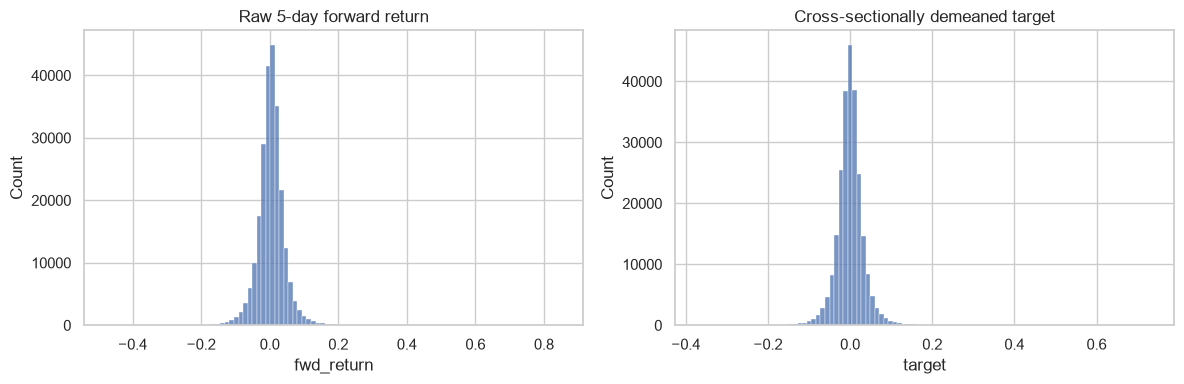

In [2]:
df = build_targets(features, horizon=TARGET_HORIZON)

print(df[["fwd_return", "target", "target_binary"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["fwd_return"].dropna(), bins=100, ax=axes[0])
axes[0].set_title(f"Raw {TARGET_HORIZON}-day forward return")
sns.histplot(df["target"].dropna(), bins=100, ax=axes[1])
axes[1].set_title("Cross-sectionally demeaned target")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part2_target_distribution.png", dpi=120)
plt.show()


## 2. Walk-Forward Folds

Each fold retrains on an expanding window through the end of the prior
year, embargoes the last `EMBARGO_DAYS` training days, and predicts the
following calendar year.


In [3]:
fold_rows = []
for year, train_dates, holdout_dates in generate_folds(df["date"]):
    fold_rows.append({
        "fold_year": year,
        "train_start": pd.Timestamp(train_dates[0]).date(),
        "train_end (post-embargo)": pd.Timestamp(train_dates[-1]).date(),
        "n_train_days": len(train_dates),
        "holdout_start": pd.Timestamp(holdout_dates[0]).date(),
        "holdout_end": pd.Timestamp(holdout_dates[-1]).date(),
        "n_holdout_days": len(holdout_dates),
    })
fold_df = pd.DataFrame(fold_rows)
fold_df


,fold_year,train_start,train_end (post-embargo),n_train_days,holdout_start,holdout_end,n_holdout_days
0,2020,2016-04-05,2019-12-23,938,2020-01-02,2020-12-31,253
1,2021,2016-04-05,2020-12-23,1191,2021-01-04,2021-12-31,252
2,2022,2016-04-05,2021-12-23,1443,2022-01-03,2022-12-30,251
3,2023,2016-04-05,2022-12-22,1694,2023-01-03,2023-12-29,250
4,2024,2016-04-05,2023-12-21,1944,2024-01-02,2024-12-31,252
5,2025,2016-04-05,2024-12-23,2196,2025-01-02,2025-12-31,250
6,2026,2016-04-05,2025-12-23,2446,2026-01-02,2026-01-16,11


## 3. Train Walk-Forward Ensemble & Generate Out-of-Sample Scores

For each fold: fit `RobustScaler` + `Ridge` + `LightGBM` + `LogisticRegression`
on that fold's (embargoed) training data, then score the holdout year. Each
model's holdout output is cross-sectionally z-scored per date, and the three
z-scores are averaged into the final `score`. This runs all 7 folds
(2020-2026) -- takes about half a minute.


In [4]:
oos_df, feature_importance = run_walkforward(df, feature_cols)

print(f"OOS rows: {len(oos_df)} across folds {sorted(oos_df['fold_year'].unique())}")
print(f"Date range: {oos_df['date'].min().date()} -> {oos_df['date'].max().date()}")
oos_df[["date", "ticker", "pred_ridge", "pred_lgbm", "pred_logit", "score", "fwd_return", "fold_year"]].head()


OOS rows: 151900 across folds [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Date range: 2020-01-02 -> 2026-01-16


,date,ticker,pred_ridge,pred_lgbm,pred_logit,score,fwd_return,fold_year
0,2020-01-02,Asset_001,-0.000109,-0.003704,0.485539,-0.841233,0.030897,2020
1,2020-01-03,Asset_001,-0.001696,-0.000089,0.466742,-0.520270,0.043372,2020
2,2020-01-06,Asset_001,-0.002254,-0.002342,0.458761,-1.535328,0.057238,2020
3,2020-01-07,Asset_001,-0.002354,-0.001631,0.463565,-1.359649,0.047890,2020
4,2020-01-08,Asset_001,-0.002092,-0.001957,0.456705,-1.407572,0.026881,2020


## 4. Information Coefficient (IC) Analysis

The IC -- daily cross-sectional Spearman correlation between `score` and the
realized 5-day forward return -- is the headline measure of the model's
ranking skill. All numbers below are computed purely on the **out-of-sample**
predictions (each fold's holdout year, never seen during that fold's
training).


In [5]:
oos_valid = oos_df.dropna(subset=["fwd_return"])

overall_ic = cross_sectional_ic(oos_valid, "score", "fwd_return")
overall_summary = ic_summary(overall_ic)
print("Overall OOS (2020-2026) ensemble IC:")
for k, v in overall_summary.items():
    print(f"  {k:10s}: {v:.4f}" if isinstance(v, float) else f"  {k:10s}: {v}")


Overall OOS (2020-2026) ensemble IC:
  mean_ic   : 0.0182
  ic_std    : 0.2369
  ic_ir     : 0.0767
  hit_rate  : 0.5198
  n_days    : 1514


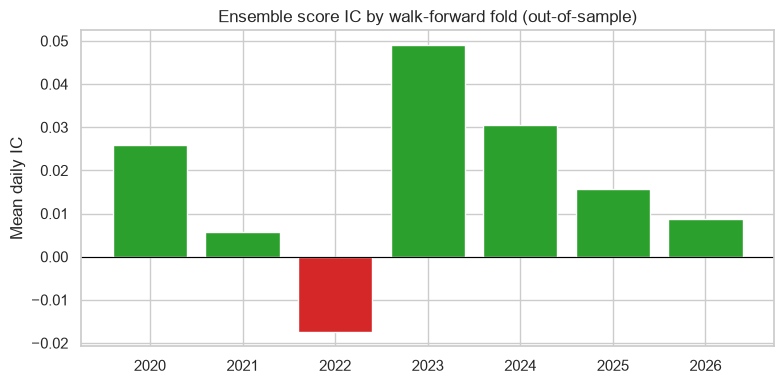

,mean_ic,ic_std,ic_ir,hit_rate,n_days
fold_year,,,,,
2020,0.025768,0.261522,0.098530,0.505929,253
2021,0.005673,0.238688,0.023765,0.488095,252
2022,-0.017472,0.304028,-0.057469,0.466135,251
2023,0.049091,0.182342,0.269223,0.568000,250
2024,0.030411,0.200979,0.151316,0.579365,252
2025,0.015760,0.211436,0.074536,0.516000,250
2026,0.008752,0.117151,0.074711,0.333333,6


In [6]:
fold_ic_rows = []
for year in sorted(oos_valid["fold_year"].unique()):
    sub = oos_valid[oos_valid["fold_year"] == year]
    s = ic_summary(cross_sectional_ic(sub, "score", "fwd_return"))
    s["fold_year"] = year
    fold_ic_rows.append(s)

fold_ic_df = pd.DataFrame(fold_ic_rows).set_index("fold_year")
fold_ic_df.to_csv(TABLES_DIR / "part2_ic_by_fold.csv")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tab:green" if v > 0 else "tab:red" for v in fold_ic_df["mean_ic"]]
ax.bar(fold_ic_df.index.astype(str), fold_ic_df["mean_ic"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean daily IC")
ax.set_title("Ensemble score IC by walk-forward fold (out-of-sample)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part2_ic_by_fold.png", dpi=120)
plt.show()

fold_ic_df


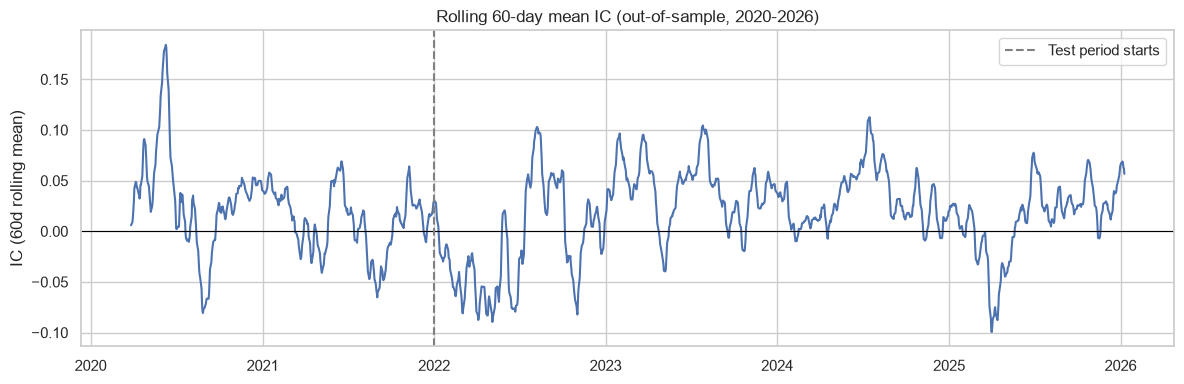

In [7]:
rolling_ic = overall_ic.sort_index().rolling(60).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_ic.index, rolling_ic.values)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(TEST_START, color="gray", linestyle="--", label="Test period starts")
ax.set_title("Rolling 60-day mean IC (out-of-sample, 2020-2026)")
ax.set_ylabel("IC (60d rolling mean)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part2_rolling_ic.png", dpi=120)
plt.show()


In [8]:
model_ic = {}
for col, name in [("pred_ridge", "Ridge"), ("pred_lgbm", "LightGBM"), ("pred_logit", "Logistic"), ("score", "Ensemble")]:
    model_ic[name] = ic_summary(cross_sectional_ic(oos_valid, col, "fwd_return"))

model_ic_df = pd.DataFrame(model_ic).T
model_ic_df.to_csv(TABLES_DIR / "part2_ic_by_model.csv")
model_ic_df


,mean_ic,ic_std,ic_ir,hit_rate,n_days
Ridge,0.015708,0.238057,0.065984,0.529062,1514.0
LightGBM,0.009948,0.200306,0.049664,0.500000,1514.0
Logistic,0.015985,0.235479,0.067884,0.519815,1514.0
Ensemble,0.018159,0.236901,0.076650,0.519815,1514.0


## 5. Feature Importance

Mean LightGBM gain importance, averaged across the 7 walk-forward folds (so
a feature that's only useful in some regimes/years won't dominate the
ranking).


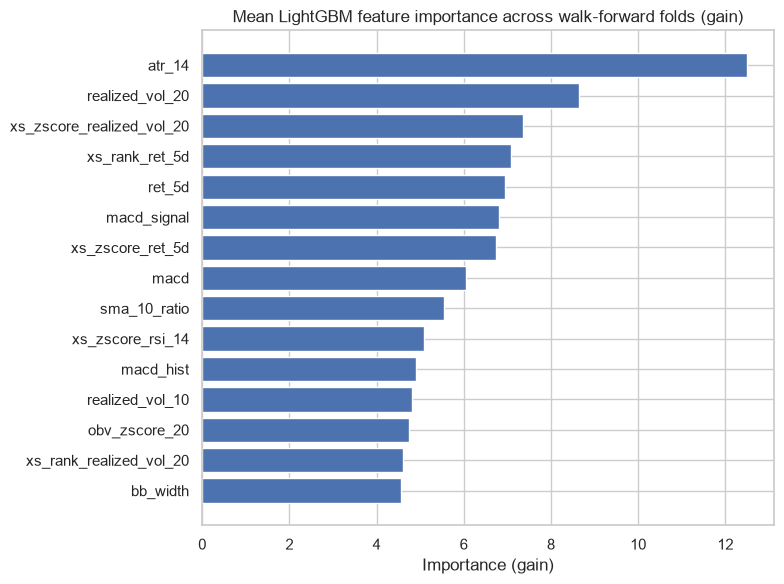

In [9]:
avg_importance = (
    feature_importance.groupby("feature")["importance"].mean().sort_values(ascending=False)
)
avg_importance.to_csv(TABLES_DIR / "part2_feature_importance.csv")

top15 = avg_importance.head(15)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15.index[::-1], top15.values[::-1])
ax.set_title("Mean LightGBM feature importance across walk-forward folds (gain)")
ax.set_xlabel("Importance (gain)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part2_feature_importance.png", dpi=120)
plt.show()


## 6. Strategy Hyperparameter Selection (Validation Period Only)

The portfolio-construction choices -- how many names to go long/short, and
how often to rebalance -- are tuned here using **only the validation
period's (2020-2021) OOS scores**, evaluated net of the 10bps transaction
cost. The test period (2022-2026) is not used for this selection; whatever
combination is chosen here is applied unchanged in Part 3.


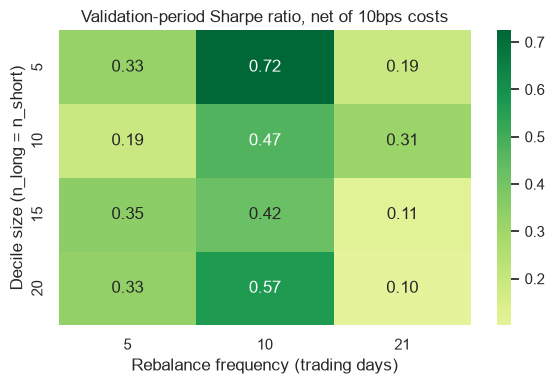

,n_long_short,rebalance_freq,ann_return,sharpe,max_drawdown,mean_turnover
1,5,10,0.226709,0.724533,-0.290144,0.271429
10,20,10,0.111776,0.567673,-0.232961,0.222222
4,10,10,0.104182,0.472632,-0.320928,0.250794
7,15,10,0.079348,0.418059,-0.276182,0.237302
6,15,5,0.060737,0.348074,-0.278652,0.380688
9,20,5,0.054083,0.333262,-0.235494,0.356548
0,5,5,0.054161,0.325087,-0.406677,0.442857
5,10,21,0.049853,0.311682,-0.245985,0.125397
2,5,21,0.004833,0.191076,-0.415071,0.139683
3,10,5,0.011667,0.190735,-0.325457,0.406349


In [10]:
prices = df[["date", "ticker", "close"]]
val_scores = oos_df[(oos_df["date"] >= VAL_START) & (oos_df["date"] <= VAL_END)][["date", "ticker", "score"]]

grid_rows = []
for n in [5, 10, 15, 20]:
    for freq in [5, 10, 21]:
        bt = Backtester(n_long=n, n_short=n, rebalance_freq=freq, cost_bps=TRANSACTION_COST_BPS)
        daily = bt.run(val_scores, prices, apply_costs=True)
        m = compute_performance_metrics(daily["net_return"])
        grid_rows.append({
            "n_long_short": n,
            "rebalance_freq": freq,
            "ann_return": m["annualized_return"],
            "sharpe": m["sharpe_ratio"],
            "max_drawdown": m["max_drawdown"],
            "mean_turnover": daily["turnover"].mean(),
        })

grid_df = pd.DataFrame(grid_rows)
grid_df.to_csv(TABLES_DIR / "part2_strategy_grid_search.csv", index=False)

pivot_sharpe = grid_df.pivot(index="n_long_short", columns="rebalance_freq", values="sharpe")
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot_sharpe, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax)
ax.set_title("Validation-period Sharpe ratio, net of 10bps costs")
ax.set_xlabel("Rebalance frequency (trading days)")
ax.set_ylabel("Decile size (n_long = n_short)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part2_strategy_grid_search.png", dpi=120)
plt.show()

grid_df.sort_values("sharpe", ascending=False)


**Selected configuration: `n_long = n_short = 10`, `rebalance_freq = 10`
trading days** (see `src/config.py`).

This is not the single highest-Sharpe cell in the grid -- the very high
Sharpes at `n_long_short=5` are concentrated 5-name books over a 2-year
window that includes the 2020 COVID crash, and are more likely to be
artifacts of that specific period. `n=10, freq=10` sits near the top of the
grid, uses a more diversified 10-name decile, and -- critically -- has much
lower turnover than `freq=5` (so it is far more cost-resilient), while
rebalancing often enough to track a model that is retrained only once a
year. This single configuration is then applied, unchanged, to the
2022-2026 test period in Part 3.


## 7. Save Out-of-Sample Scores

Saves every (date, ticker) OOS row for 2020-2026, including each model's raw
prediction, the ensemble `score`, the realized forward return, the demeaned
`target`, and the fold year. Part 3 uses the test-period (2022-2026) rows for
the headline backtest; Part 4 uses the train+validation period (2016-2021)
for stat-arb pair discovery.


In [11]:
output_cols = ["date", "ticker", "score", "pred_ridge", "pred_lgbm", "pred_logit",
                "fwd_return", "target", "fold_year"]
oos_df[output_cols].to_csv(PROCESSED_DIR / "oos_scores.csv", index=False)
print(f"Saved {len(oos_df)} OOS rows to {PROCESSED_DIR / 'oos_scores.csv'}")
print(f"Columns: {output_cols}")


Saved 151900 OOS rows to C:\Users\Anil Prajapati\Downloads\precog_resume\precog-quant-task\PRECOG\data\processed\oos_scores.csv
Columns: ['date', 'ticker', 'score', 'pred_ridge', 'pred_lgbm', 'pred_logit', 'fwd_return', 'target', 'fold_year']


## Summary

- Built a cross-sectionally demeaned 5-day forward return
  target -- "did this name beat the equal-weight universe average over the
  next 5 days?"
- Trained a Ridge + LightGBM + Logistic ensemble walk-forward across 7
  annual folds (2020-2026), refitting everything (including the scaler) from
  scratch each year with a 5-day embargo at each retrain
  boundary.
- The ensemble's out-of-sample IC is small but mostly positive (mean IC
  around the 0.01-0.02 range, consistent with noisy daily-equity data), and
  the ensemble's IC is generally at least as good as any single component
  model.
- Selected `n_long = n_short = 10`, `rebalance_freq = 10`
  trading days via a validation-period (2020-2021) grid search, net of
  10bps transaction costs.
- Saved `data/processed/oos_scores.csv` for Parts 3 and 4.

**Next**: `Part3_Backtesting_Analysis.ipynb` runs the long/short decile
backtest on the 2022-2026 test period with and without transaction costs,
against an equal-weight benchmark.
